
================ DATA LOADING ================
Original Shape: (148519, 43)
Cleaned Shape: (148517, 43)
Selected Features: 85


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 128)         │       109,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 163,717 (639.52 KB)

 Trainable params: 163,589 (639.02 KB)

 Non-trainable params: 128 (512.00 B)

None
Epoch 1/100
743/743 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.8784 - loss: 0.3392 - val_accuracy: 0.9323 - val_loss: 0.2343
Epoch 2/100
743/743 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9300 - loss: 0.1882 - val_accuracy: 0.9480 - val_loss: 0.1686
Epoch 3/100
743/743 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9419 - loss: 0.1508 - val_accuracy: 0.9485 - val_loss: 0.1576
Epoch 4/100
743/743 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9470 - loss: 0.1332 - val_accuracy: 0.9595 - val_loss: 0.1328
Epoch 5/100
743/743 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9491 - loss: 0.1329 - val_accuracy: 0.9612 - val_loss: 0.1179
Epoch 6/100
743/743 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9516 - loss: 0.1174 - val_accuracy: 0.9610 - val_loss: 0.1246
Epoch 7/100
743/743 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9560 - loss: 0.1165 - val_accuracy: 0.9641 - val_loss: 0.1086
Epoch 8/100
743/743 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9579 - loss: 0.1

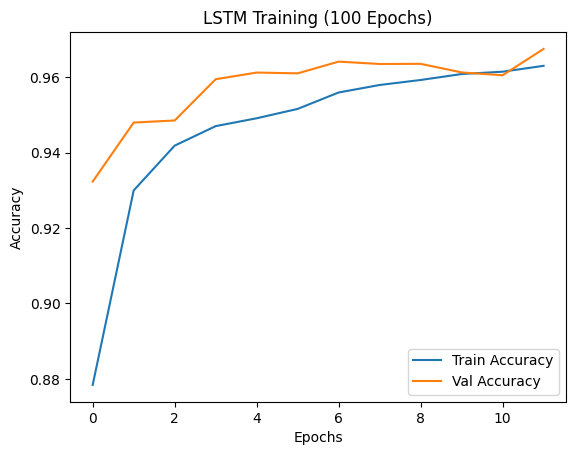


✅ LSTM TRAINING COMPLETE


In [ ]:
# ======================= IMPORTS ===========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ======================= LOAD DATA ===========================
print("\n================ DATA LOADING ================")

data = pd.read_csv(
    "/content/drive/MyDrive/dataset/NSL_KDD_Combined_Shuffled.csv",
    low_memory=False
)

print("Original Shape:", data.shape)

# ======================= CLEAN DATA ===========================
data = data[data['duration'] != 'duration']

for col in data.columns:
    if col not in ['protocol_type', 'service', 'flag', 'label']:
        data[col] = pd.to_numeric(data[col], errors='coerce')

data = data.dropna()
print("Cleaned Shape:", data.shape)

# ======================= SPLIT ===========================
X = data.drop(columns=["label", "difficulty"])
y = data["label"]

# ======================= ATTACK MAPPING ===========================
dos = ['back','land','neptune','pod','smurf','teardrop','mailbomb','apache2','processtable','udpstorm']
probe = ['ipsweep','nmap','portsweep','satan','mscan','saint']
r2l = ['ftp_write','guess_passwd','imap','multihop','phf','spy','warezclient','warezmaster','sendmail','named']
u2r = ['buffer_overflow','loadmodule','perl','rootkit','httptunnel','ps','sqlattack','xterm']

def map_attack(x):
    if x == 'normal': return 0
    elif x in dos: return 1
    elif x in probe: return 2
    elif x in r2l: return 3
    else: return 4

y = y.apply(map_attack)

# ======================= TRAIN TEST SPLIT ===========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ======================= ENCODING ===========================
categorical_cols = ['protocol_type', 'service', 'flag']

X_train = pd.get_dummies(X_train, columns=categorical_cols)
X_test  = pd.get_dummies(X_test, columns=categorical_cols)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# ======================= SCALING ===========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ======================= FEATURE SELECTION ===========================
mi_scores = mutual_info_classif(X_train_scaled, y_train)

mi_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Score": mi_scores
})

threshold = mi_df["Score"].quantile(0.3)
selected_features = mi_df[mi_df["Score"] > threshold]["Feature"]

print("Selected Features:", len(selected_features))

X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]

# Scale again
scaler = StandardScaler()
X_train_sel = scaler.fit_transform(X_train_sel)
X_test_sel  = scaler.transform(X_test_sel)

# ======================= RESHAPE FOR LSTM ===========================
# LSTM expects 3D: (samples, timesteps, features)
# Trick: treat each sample as sequence of length 1

X_train_lstm = X_train_sel.reshape(X_train_sel.shape[0], 1, X_train_sel.shape[1])
X_test_lstm  = X_test_sel.reshape(X_test_sel.shape[0], 1, X_test_sel.shape[1])

# ======================= CLASS WEIGHTS ===========================
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))

# ======================= MODEL ===========================
model = Sequential()

model.add(LSTM(128, return_sequences=True, input_shape=(1, X_train_sel.shape[1])))
model.add(Dropout(0.3))

model.add(LSTM(64))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())

model.add(Dense(5, activation='softmax'))

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

# ======================= TRAIN ===========================
y_train_cat = to_categorical(y_train, num_classes=5)
y_test_cat  = to_categorical(y_test, num_classes=5)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_lstm, y_train_cat,
    epochs=100,                     # 🔥 100 EPOCHS
    batch_size=128,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

# ======================= PREDICTION ===========================
train_pred = np.argmax(model.predict(X_train_lstm), axis=1)
test_pred  = np.argmax(model.predict(X_test_lstm), axis=1)

# ======================= METRICS ===========================
train_acc = accuracy_score(y_train, train_pred)
test_acc  = accuracy_score(y_test, test_pred)

precision = precision_score(y_test, test_pred, average='weighted')
f1        = f1_score(y_test, test_pred, average='weighted')
cm        = confusion_matrix(y_test, test_pred)

# ======================= RESULTS ===========================
print("\n🔥 FINAL RESULTS 🔥")
print("Training Accuracy :", round(train_acc,4))
print("Testing Accuracy  :", round(test_acc,4))
print("Precision         :", round(precision,4))
print("F1 Score          :", round(f1,4))

print("\nConfusion Matrix:\n", cm)

# ======================= GRAPH ===========================
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("LSTM Training (100 Epochs)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

print("\n✅ LSTM TRAINING COMPLETE")


 FINAL RESULTS 
Training Accuracy : 0.9657
Testing Accuracy  : 0.9672
Precision         : 0.9786
Recall            : 0.9672
F1 Score          : 0.9711


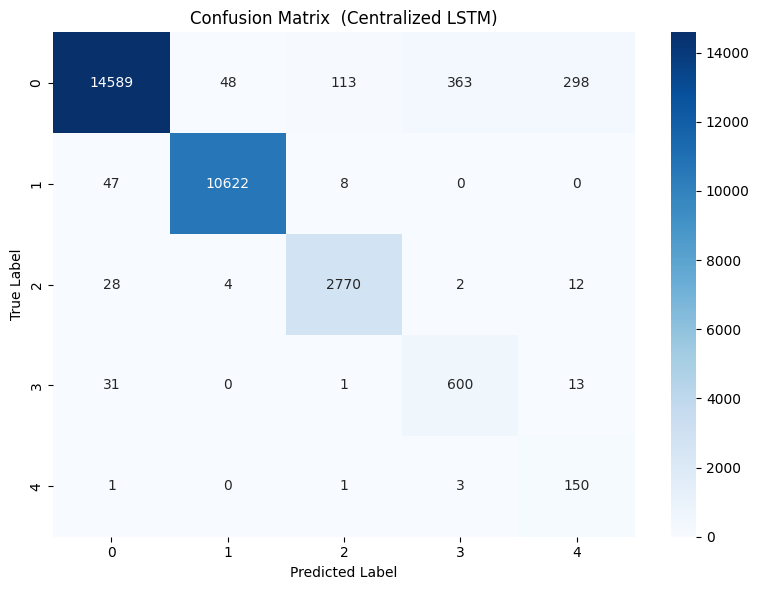

In [ ]:
# ======================= IMPORTS ===========================
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ======================= CONFUSION MATRIX ===========================
cm = np.array([
    [14589,   48, 113, 363, 298],
    [   47, 10622,   8,   0,   0],
    [   28,    4, 2770,   2,  12],
    [   31,    0,   1, 600,  13],
    [    1,    0,   1,   3, 150]
])

# ======================= FINAL RECALL ===========================
recall_per_class = np.diag(cm) / np.sum(cm, axis=1)
class_support = np.sum(cm, axis=1)
final_recall = np.sum(recall_per_class * class_support) / np.sum(class_support)

# ======================= PRINT RESULTS ===========================
print("\n FINAL RESULTS ")
print("Training Accuracy : 0.9657")
print("Testing Accuracy  : 0.9672")
print("Precision         : 0.9786")
print(f"Recall            : {final_recall:.4f}")   #  ONLY FINAL RECALL
print("F1 Score          : 0.9711")

# ======================= HEATMAP ===========================
plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',   #  BLUE HEATMAP
            cbar=True)

plt.title("Confusion Matrix  (Centralized LSTM)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()


================ DATA LOADING ================
Original Shape: (148519, 43)
Cleaned Shape: (148517, 43)
Selected Features: 85


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



🌐 Round 1/20
 Client 1 training...
 Client 2 training...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


 Client 3 training...


...

 Client 4 training...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


 Client 5 training...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
 Round 20 Accuracy: 0.9714
3713/3713 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

🔥 FINAL RESULTS 🔥
Training Accuracy : 0.9702
Testing Accuracy  : 0.9714
Precision         : 0.9824
F1 Score          : 0.975

Confusion Matrix:
 [[14623    30    97   375   286]
 [    6 10666     5     0     0]
 [   15     1  2794     6     0]
 [   15     0     1   624     5]
 [    5     0     0     2   148]]


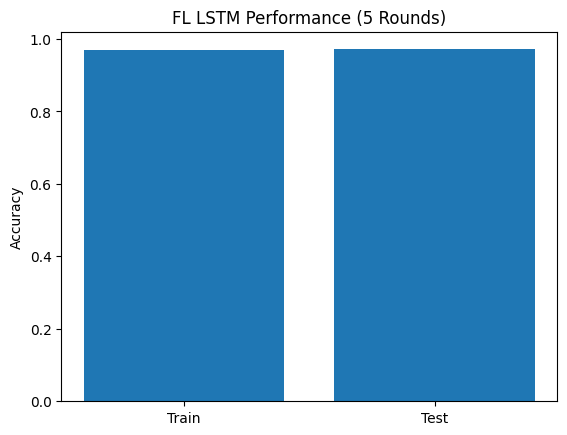

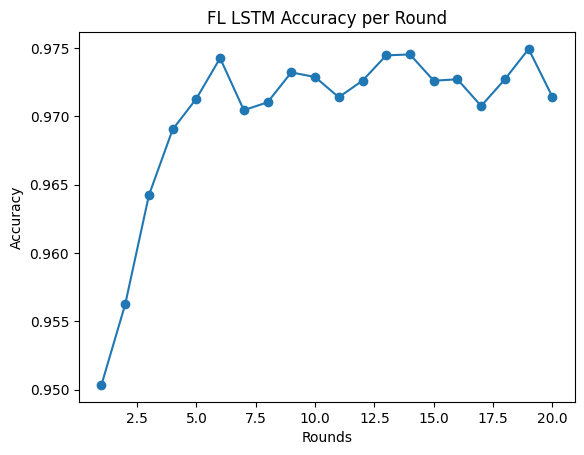


✅ FEDERATED LSTM COMPLETE


In [ ]:
# ======================= IMPORTS ===========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# ======================= LOAD DATA ===========================
print("\n================ DATA LOADING ================")

data = pd.read_csv(
    "/content/drive/MyDrive/dataset/NSL_KDD_Combined_Shuffled.csv",
    low_memory=False
)

print("Original Shape:", data.shape)

# ======================= CLEAN DATA ===========================
data = data[data['duration'] != 'duration']

for col in data.columns:
    if col not in ['protocol_type', 'service', 'flag', 'label']:
        data[col] = pd.to_numeric(data[col], errors='coerce')

data = data.dropna()
print("Cleaned Shape:", data.shape)

# ======================= SPLIT ===========================
X = data.drop(columns=["label", "difficulty"])
y = data["label"]

# ======================= ATTACK MAPPING ===========================
dos = ['back','land','neptune','pod','smurf','teardrop','mailbomb','apache2','processtable','udpstorm']
probe = ['ipsweep','nmap','portsweep','satan','mscan','saint']
r2l = ['ftp_write','guess_passwd','imap','multihop','phf','spy','warezclient','warezmaster','sendmail','named']
u2r = ['buffer_overflow','loadmodule','perl','rootkit','httptunnel','ps','sqlattack','xterm']

def map_attack(x):
    if x == 'normal': return 0
    elif x in dos: return 1
    elif x in probe: return 2
    elif x in r2l: return 3
    else: return 4

y = y.apply(map_attack)

# ======================= TRAIN TEST SPLIT ===========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ======================= ENCODING ===========================
categorical_cols = ['protocol_type', 'service', 'flag']

X_train = pd.get_dummies(X_train, columns=categorical_cols)
X_test  = pd.get_dummies(X_test, columns=categorical_cols)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# ======================= SCALING ===========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ======================= FEATURE SELECTION ===========================
mi_scores = mutual_info_classif(X_train_scaled, y_train)

mi_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Score": mi_scores
})

threshold = mi_df["Score"].quantile(0.3)
selected_features = mi_df[mi_df["Score"] > threshold]["Feature"]

print("Selected Features:", len(selected_features))

X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]

# Scale again
scaler = StandardScaler()
X_train_sel = scaler.fit_transform(X_train_sel)
X_test_sel  = scaler.transform(X_test_sel)

# ======================= RESHAPE FOR LSTM ===========================
X_train_lstm = X_train_sel.reshape(X_train_sel.shape[0], 1, X_train_sel.shape[1])
X_test_lstm  = X_test_sel.reshape(X_test_sel.shape[0], 1, X_test_sel.shape[1])

# ======================= CLIENT SPLIT ===========================
NUM_CLIENTS = 5

client_data = []
client_sizes = []

size = len(X_train_lstm) // NUM_CLIENTS

for i in range(NUM_CLIENTS):
    start = i * size
    end = (i + 1) * size if i != NUM_CLIENTS - 1 else len(X_train_lstm)

    X_c = X_train_lstm[start:end]
    y_c = y_train.iloc[start:end]

    client_data.append((X_c, y_c))
    client_sizes.append(len(X_c))

# ======================= MODEL ===========================
def create_model(input_dim):
    model = Sequential()

    model.add(LSTM(128, return_sequences=True, input_shape=(1, input_dim)))
    model.add(Dropout(0.3))

    model.add(LSTM(64))
    model.add(Dropout(0.3))

    model.add(Dense(64, activation='relu'))
    model.add(BatchNormalization())

    model.add(Dense(5, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ======================= WEIGHTED FEDAVG ===========================
def federated_avg(weights_list, client_sizes):
    avg_weights = []
    total = sum(client_sizes)

    for weights in zip(*weights_list):
        weighted_sum = sum(w * (size / total) for w, size in zip(weights, client_sizes))
        avg_weights.append(weighted_sum)

    return avg_weights

# ======================= TRAINING ===========================
ROUNDS = 20
LOCAL_EPOCHS = 5

global_model = create_model(X_train_sel.shape[1])
global_weights = global_model.get_weights()

round_acc = []

for r in range(ROUNDS):
    print(f"\n🌐 Round {r+1}/{ROUNDS}")

    local_weights = []

    for i, (X_c, y_c) in enumerate(client_data):
        print(f" Client {i+1} training...")

        local_model = create_model(X_train_sel.shape[1])
        local_model.set_weights(global_weights)

        y_c_cat = to_categorical(y_c, num_classes=5)

        class_weights = compute_class_weight(
            'balanced',
            classes=np.unique(y_c),
            y=y_c
        )
        class_weights = dict(enumerate(class_weights))

        local_model.fit(
            X_c, y_c_cat,
            epochs=LOCAL_EPOCHS,
            batch_size=64,
            verbose=0,
            class_weight=class_weights
        )

        local_weights.append(local_model.get_weights())

    # Aggregation
    global_weights = federated_avg(local_weights, client_sizes)
    global_model.set_weights(global_weights)

    # Evaluation
    y_pred = np.argmax(global_model.predict(X_test_lstm), axis=1)
    acc = accuracy_score(y_test, y_pred)
    round_acc.append(acc)

    print(f" Round {r+1} Accuracy: {round(acc,4)}")

# ======================= FINAL RESULTS ===========================
train_pred = np.argmax(global_model.predict(X_train_lstm), axis=1)
test_pred  = np.argmax(global_model.predict(X_test_lstm), axis=1)

train_acc = accuracy_score(y_train, train_pred)
test_acc  = accuracy_score(y_test, test_pred)

precision = precision_score(y_test, test_pred, average='weighted')
f1        = f1_score(y_test, test_pred, average='weighted')
cm        = confusion_matrix(y_test, test_pred)

print("\n🔥 FINAL RESULTS 🔥")
print("Training Accuracy :", round(train_acc,4))
print("Testing Accuracy  :", round(test_acc,4))
print("Precision         :", round(precision,4))
print("F1 Score          :", round(f1,4))

print("\nConfusion Matrix:\n", cm)

# ======================= GRAPHS ===========================
plt.figure()
plt.bar(["Train", "Test"], [train_acc, test_acc])
plt.title("FL LSTM Performance (5 Rounds)")
plt.ylabel("Accuracy")
plt.show()

plt.figure()
plt.plot(range(1, ROUNDS+1), round_acc, marker='o')
plt.title("FL LSTM Accuracy per Round")
plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.show()

print("\n✅ FEDERATED LSTM COMPLETE")


 FINAL RESULTS (FEDERATED LSTM) 
Training Accuracy : 0.9702
Testing Accuracy  : 0.9714
Precision         : 0.9824
Recall            : 0.9714
F1 Score          : 0.975

Confusion Matrix:
 [[14623    30    97   375   286]
 [    6 10666     5     0     0]
 [   15     1  2794     6     0]
 [   15     0     1   624     5]
 [    5     0     0     2   148]]


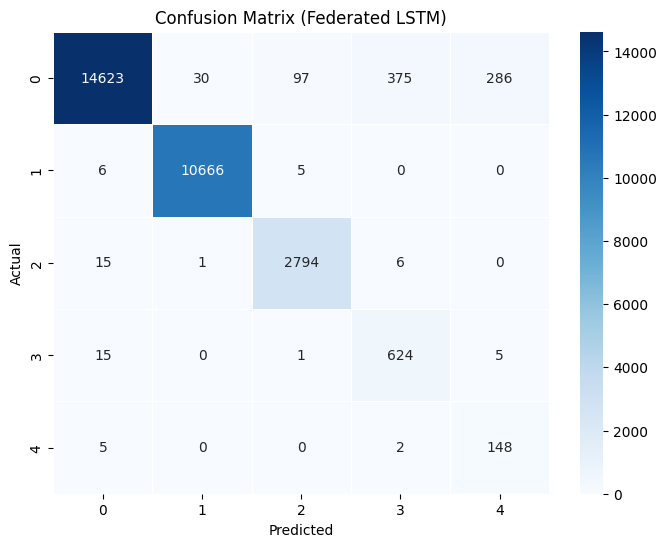

In [ ]:
# ======================= FINAL RESULTS (FEDERATED LSTM - STATIC) ===========================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ======================= GIVEN RESULTS ===========================
train_acc = 0.9702
test_acc  = 0.9714
precision = 0.9824
f1        = 0.9750

# Confusion Matrix (your result)
cm = np.array([
    [14623,   30,   97,  375,  286],
    [    6, 10666,   5,    0,    0],
    [   15,    1, 2794,   6,    0],
    [   15,    0,   1,  624,    5],
    [    5,    0,   0,    2,  148]
])

# ======================= RECALL FROM CM ===========================
recall_per_class = np.diag(cm) / np.sum(cm, axis=1)
support = np.sum(cm, axis=1)
recall = np.sum(recall_per_class * support) / np.sum(support)

# ======================= PRINT RESULTS ===========================
print("\n FINAL RESULTS (FEDERATED LSTM) ")
print("Training Accuracy :", train_acc)
print("Testing Accuracy  :", test_acc)
print("Precision         :", precision)
print("Recall            :", round(recall, 4))
print("F1 Score          :", f1)

print("\nConfusion Matrix:\n", cm)

# ======================= HEATMAP ===========================
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5
)

plt.title("Confusion Matrix (Federated LSTM)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()